In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

In [3]:
data_path = Path("data/")

In [4]:
image_path = data_path / "desert101"

In [5]:
image_path

WindowsPath('data/desert101')

In [6]:
import os 

In [8]:
def check_data(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"# of directorie: {len(dirnames)} and {len(filenames)} images in {dirpath}")

In [10]:
check_data(image_path)

# of directorie: 2 and 1 images in data\desert101
# of directorie: 4 and 1 images in data\desert101\test
# of directorie: 0 and 20 images in data\desert101\test\baklava
# of directorie: 0 and 20 images in data\desert101\test\cannoli
# of directorie: 0 and 20 images in data\desert101\test\cup_cakes
# of directorie: 0 and 20 images in data\desert101\test\donuts
# of directorie: 4 and 1 images in data\desert101\train
# of directorie: 0 and 80 images in data\desert101\train\baklava
# of directorie: 0 and 80 images in data\desert101\train\cannoli
# of directorie: 0 and 80 images in data\desert101\train\cup_cakes
# of directorie: 0 and 80 images in data\desert101\train\donuts


In [14]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [15]:
train_dir

WindowsPath('data/desert101/train')

In [16]:
test_dir

WindowsPath('data/desert101/test')

In [18]:
from PIL import Image

In [19]:
import random

In [34]:
random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image = random.choice(image_path_list)
img = Image.open(random_image)

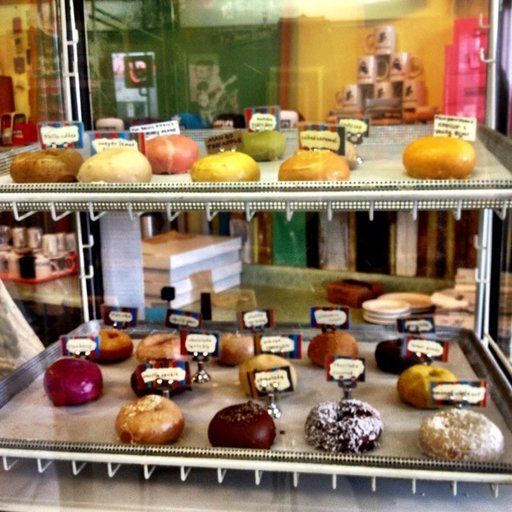

In [35]:
img

In [36]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [38]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()
])

In [39]:
train_data = datasets.ImageFolder(root=train_dir,
                                 transform = data_transform,
                                target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform = data_transform,
                                target_transform=None)

In [40]:
test_data

Dataset ImageFolder
    Number of datapoints: 77
    Root location: data\desert101\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [41]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: data\desert101\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [42]:
class_names = train_data.classes

In [43]:
class_names

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [44]:
len(train_data), len(test_data)

(316, 77)

In [45]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

In [46]:
NUM_WORKERS

16

In [48]:
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers = NUM_WORKERS,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              num_workers = NUM_WORKERS,
                              shuffle=False)

In [51]:
train_dataloader.dataset[0][0]

tensor([[[0.6000, 0.5922, 0.5333,  ..., 0.4784, 0.4510, 0.4549],
         [0.6431, 0.5529, 0.5098,  ..., 0.5294, 0.4471, 0.4706],
         [0.6863, 0.5412, 0.5608,  ..., 0.5843, 0.4667, 0.5490],
         ...,
         [0.9490, 0.9686, 0.9804,  ..., 0.8353, 0.8196, 0.8000],
         [0.9451, 0.9804, 0.9882,  ..., 0.7922, 0.8039, 0.8196],
         [0.9373, 0.9608, 0.9529,  ..., 0.8314, 0.8510, 0.8196]],

        [[0.4824, 0.4784, 0.4196,  ..., 0.3451, 0.3137, 0.3216],
         [0.5294, 0.4471, 0.4000,  ..., 0.4078, 0.3333, 0.3569],
         [0.5725, 0.4353, 0.4392,  ..., 0.4549, 0.3412, 0.4078],
         ...,
         [0.7098, 0.7686, 0.8196,  ..., 0.5961, 0.5725, 0.5451],
         [0.7216, 0.8118, 0.8275,  ..., 0.5569, 0.5686, 0.5765],
         [0.7098, 0.7647, 0.7647,  ..., 0.6314, 0.6431, 0.6000]],

        [[0.2118, 0.2157, 0.1686,  ..., 0.0980, 0.0824, 0.0902],
         [0.2314, 0.1804, 0.1490,  ..., 0.1490, 0.1020, 0.1137],
         [0.2510, 0.1725, 0.1529,  ..., 0.1765, 0.1059, 0.

In [56]:
class DesertClassifier(nn.Module):
    def __init__(self,input_shape:int, hidden_units: int, output_shape:int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
        out_channels=hidden_units,
        kernel_size=3,
        stride=1,
        padding=1),
        nn.ReLU(),

        nn.Conv2d(in_channels=hidden_units,
        out_channels=hidden_units,
        kernel_size=3,
        stride=1,
        padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
        stride=2)
        )
        self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
        out_channels=hidden_units,
        kernel_size=3,
        stride=1,
        padding=1),
        nn.ReLU(),

        nn.Conv2d(in_channels=hidden_units,
        out_channels=hidden_units,
        kernel_size=3,
        stride=1,
        padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
        stride=2)
        )

        self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*16*16,
                 out_features=output_shape)
        )
    def forward(self,x):
            return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [54]:
x = torch.randn(1,3,64,64)

print("Input: ",x.shape)

conv1 = nn.Conv2d(in_channels=3,
                    out_channels = 10,
                    kernel_size=3,
                    stride = 1,
                    padding=1)
conv2 = nn.Conv2d(in_channels=10,
                    out_channels = 10,
                    kernel_size=3,
                    stride = 1,
                    padding=1)
pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

x = conv1(x)
print("After Conv1: ", x.shape)

x = conv2(x)
print("After Conv2: ",x.shape)

x = pool1(x)
print("After Pool1 : ",x.shape)

conv3 = nn.Conv2d(in_channels=10,
                    out_channels = 10,
                    kernel_size=3,
                    stride = 1,
                    padding=1)
conv4 = nn.Conv2d(in_channels=10,
                    out_channels = 10,
                    kernel_size=3,
                    stride = 1,
                    padding=1)
pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

x = conv3(x)
print("After Conv3: ", x.shape)

x = conv4(x)
print("After Conv4: ",x.shape)

x = pool2(x)
print("After Pool2 : ",x.shape)

Input:  torch.Size([1, 3, 64, 64])
After Conv1:  torch.Size([1, 10, 64, 64])
After Conv2:  torch.Size([1, 10, 64, 64])
After Pool1 :  torch.Size([1, 10, 32, 32])
After Conv3:  torch.Size([1, 10, 32, 32])
After Conv4:  torch.Size([1, 10, 32, 32])
After Pool2 :  torch.Size([1, 10, 16, 16])


In [55]:
10*16*16

2560

In [57]:
model_0 = DesertClassifier(input_shape=3,
                            hidden_units=32,
                           output_shape=len(class_names))

In [58]:
len(class_names)

4

In [59]:
!pip install torchinfo

In [60]:
from torchinfo import summary

In [62]:
summary(model_0,input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [63]:
16*16*32

8192

In [64]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer):

    model.train()

    train_loss = 0
    train_acc = 0

    for batch, (X,y) in enumerate(dataloader):
        y_pred = model(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1),dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [65]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

    model.eval()

    test_loss=0
    test_acc=0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [69]:
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module=nn.CrossEntropyLoss(),
          epochs :int=10):
    results = {"train_loss" : [],
               "train_acc": [],
               "test_loss" : [],
               "test_acc" : []
              }
    
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn = loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
        dataloader=test_dataloader,
        loss_fn = loss_fn)

        print(f"Epoch: {epoch}, Train Loss: {train_loss}, Train Acc: {train_acc}, Test Loss: {test_loss}, Test Acc: {test_acc}")

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
    return results

In [70]:
EPOCHS = 10
model_0 = DesertClassifier(input_shape=3,
                           hidden_units=32,
                           output_shape=len(class_names))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),lr=0.001)

model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        loss_fn=loss_fn,
                        optimizer = optimizer,
                        epochs=EPOCHS)

Epoch: 0, Train Loss: 1.4004823684692382, Train Acc: 0.2741071428571428, Test Loss: 1.3740713198979695, Test Acc: 0.23317307692307696
Epoch: 1, Train Loss: 1.383024549484253, Train Acc: 0.26919642857142856, Test Loss: 1.3719395001729329, Test Acc: 0.3774038461538461
Epoch: 2, Train Loss: 1.3719835877418518, Train Acc: 0.33392857142857146, Test Loss: 1.3804463942845662, Test Acc: 0.2604166666666667
Epoch: 3, Train Loss: 1.3374182820320129, Train Acc: 0.36741071428571426, Test Loss: 1.327922026316325, Test Acc: 0.32211538461538464
Epoch: 4, Train Loss: 1.2966020584106446, Train Acc: 0.390625, Test Loss: 1.386556347211202, Test Acc: 0.3165064102564103
Epoch: 5, Train Loss: 1.2913987278938293, Train Acc: 0.36830357142857145, Test Loss: 1.3132335344950359, Test Acc: 0.23958333333333334
Epoch: 6, Train Loss: 1.2760480999946595, Train Acc: 0.4040178571428571, Test Loss: 1.32527760664622, Test Acc: 0.3125
Epoch: 7, Train Loss: 1.2537380456924438, Train Acc: 0.4165178571428571, Test Loss: 1.335

In [71]:
model_0_results

{'train_loss': [1.4004823684692382,
  1.383024549484253,
  1.3719835877418518,
  1.3374182820320129,
  1.2966020584106446,
  1.2913987278938293,
  1.2760480999946595,
  1.2537380456924438,
  1.2790032148361206,
  1.2536322474479675],
 'train_acc': [0.2741071428571428,
  0.26919642857142856,
  0.33392857142857146,
  0.36741071428571426,
  0.390625,
  0.36830357142857145,
  0.4040178571428571,
  0.4165178571428571,
  0.38705357142857144,
  0.3977678571428572],
 'test_loss': [1.3740713198979695,
  1.3719395001729329,
  1.3804463942845662,
  1.327922026316325,
  1.386556347211202,
  1.3132335344950359,
  1.32527760664622,
  1.3357194264729817,
  1.3209366003672283,
  1.2964667876561482],
 'test_acc': [0.23317307692307696,
  0.3774038461538461,
  0.2604166666666667,
  0.32211538461538464,
  0.3165064102564103,
  0.23958333333333334,
  0.3125,
  0.3381410256410256,
  0.3269230769230769,
  0.3373397435897436]}

In [72]:
import matplotlib.pyplot as plt

In [82]:
def plot_loss_curves(results):
    loss = results["train_loss"]
    test_loss = results["test_loss"]
    train_accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(17,8))

    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("accuracy")
    plt.xlabel("Epochs")
    plt.legend()

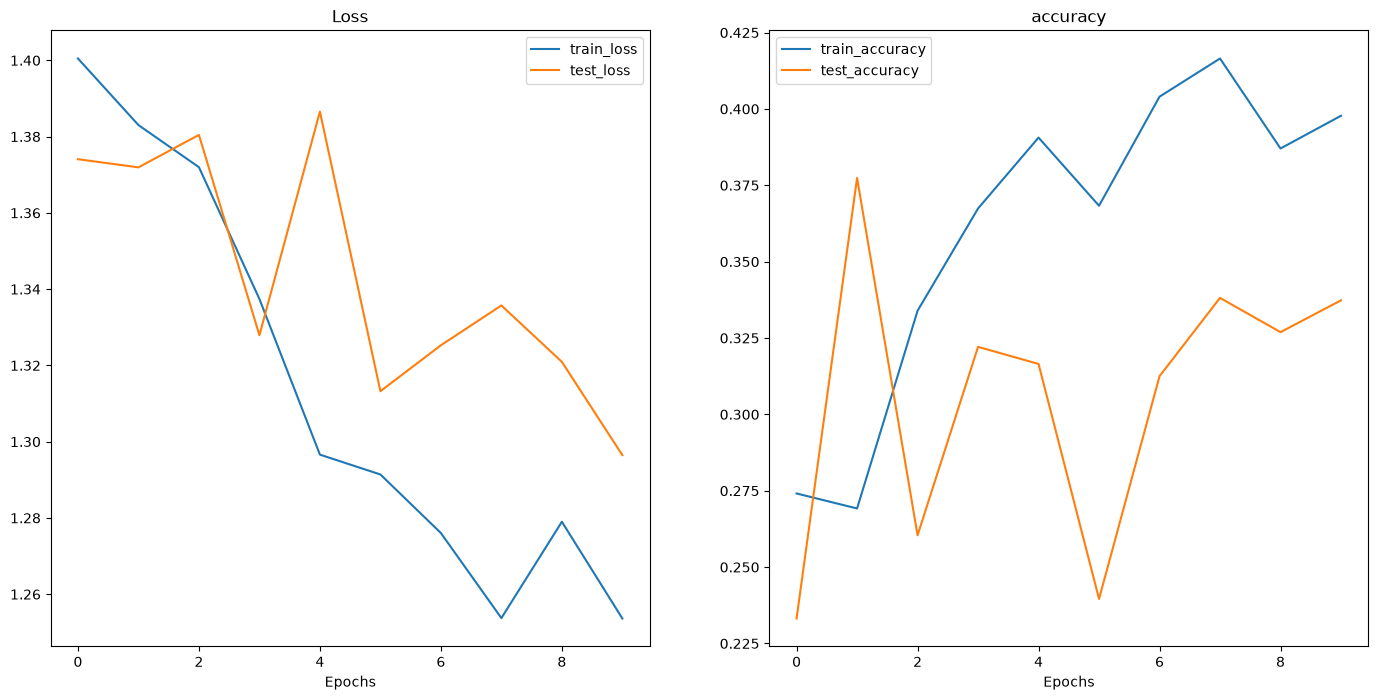

In [83]:
plot_loss_curves(model_0_results)

In [84]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [85]:
import random
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    
    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)  
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

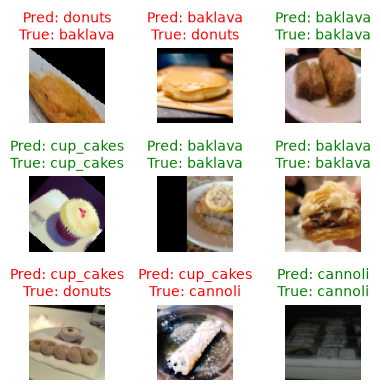

In [86]:
show_random_predictions(model_0,test_data,class_names)

In [88]:
online_image_path = data_path / "baklava-online.jpg"

In [89]:
online_image_path

WindowsPath('data/baklava-online.jpg')

In [90]:
import torchvision

In [91]:
single_image = torchvision.io.read_image(str(online_image_path))

In [92]:
single_image

tensor([[[88, 88, 89,  ..., 40, 40, 40],
         [88, 89, 89,  ..., 40, 40, 40],
         [89, 89, 89,  ..., 40, 40, 40],
         ...,
         [25, 25, 25,  ..., 60, 62, 64],
         [24, 24, 25,  ..., 60, 62, 63],
         [23, 23, 26,  ..., 58, 59, 60]],

        [[82, 82, 84,  ..., 40, 40, 40],
         [82, 83, 84,  ..., 40, 40, 40],
         [83, 83, 84,  ..., 40, 40, 40],
         ...,
         [27, 27, 27,  ..., 60, 62, 64],
         [26, 26, 27,  ..., 60, 62, 63],
         [28, 28, 28,  ..., 59, 60, 61]],

        [[30, 30, 29,  ..., 42, 42, 42],
         [30, 31, 29,  ..., 40, 40, 40],
         [31, 31, 29,  ..., 40, 40, 40],
         ...,
         [26, 26, 24,  ..., 52, 54, 56],
         [25, 25, 24,  ..., 52, 54, 55],
         [24, 24, 25,  ..., 53, 54, 53]]], dtype=torch.uint8)

In [93]:
single_image = torchvision.io.read_image(str(online_image_path)).type(torch.float32)

In [94]:
single_image

tensor([[[88., 88., 89.,  ..., 40., 40., 40.],
         [88., 89., 89.,  ..., 40., 40., 40.],
         [89., 89., 89.,  ..., 40., 40., 40.],
         ...,
         [25., 25., 25.,  ..., 60., 62., 64.],
         [24., 24., 25.,  ..., 60., 62., 63.],
         [23., 23., 26.,  ..., 58., 59., 60.]],

        [[82., 82., 84.,  ..., 40., 40., 40.],
         [82., 83., 84.,  ..., 40., 40., 40.],
         [83., 83., 84.,  ..., 40., 40., 40.],
         ...,
         [27., 27., 27.,  ..., 60., 62., 64.],
         [26., 26., 27.,  ..., 60., 62., 63.],
         [28., 28., 28.,  ..., 59., 60., 61.]],

        [[30., 30., 29.,  ..., 42., 42., 42.],
         [30., 31., 29.,  ..., 40., 40., 40.],
         [31., 31., 29.,  ..., 40., 40., 40.],
         ...,
         [26., 26., 24.,  ..., 52., 54., 56.],
         [25., 25., 24.,  ..., 52., 54., 55.],
         [24., 24., 25.,  ..., 53., 54., 53.]]])

In [95]:
single_image = single_image / 255

In [96]:
single_image

tensor([[[0.3451, 0.3451, 0.3490,  ..., 0.1569, 0.1569, 0.1569],
         [0.3451, 0.3490, 0.3490,  ..., 0.1569, 0.1569, 0.1569],
         [0.3490, 0.3490, 0.3490,  ..., 0.1569, 0.1569, 0.1569],
         ...,
         [0.0980, 0.0980, 0.0980,  ..., 0.2353, 0.2431, 0.2510],
         [0.0941, 0.0941, 0.0980,  ..., 0.2353, 0.2431, 0.2471],
         [0.0902, 0.0902, 0.1020,  ..., 0.2275, 0.2314, 0.2353]],

        [[0.3216, 0.3216, 0.3294,  ..., 0.1569, 0.1569, 0.1569],
         [0.3216, 0.3255, 0.3294,  ..., 0.1569, 0.1569, 0.1569],
         [0.3255, 0.3255, 0.3294,  ..., 0.1569, 0.1569, 0.1569],
         ...,
         [0.1059, 0.1059, 0.1059,  ..., 0.2353, 0.2431, 0.2510],
         [0.1020, 0.1020, 0.1059,  ..., 0.2353, 0.2431, 0.2471],
         [0.1098, 0.1098, 0.1098,  ..., 0.2314, 0.2353, 0.2392]],

        [[0.1176, 0.1176, 0.1137,  ..., 0.1647, 0.1647, 0.1647],
         [0.1176, 0.1216, 0.1137,  ..., 0.1569, 0.1569, 0.1569],
         [0.1216, 0.1216, 0.1137,  ..., 0.1569, 0.1569, 0.

Text(0.5, 1.0, 'torch.Size([3, 1857, 3000])')

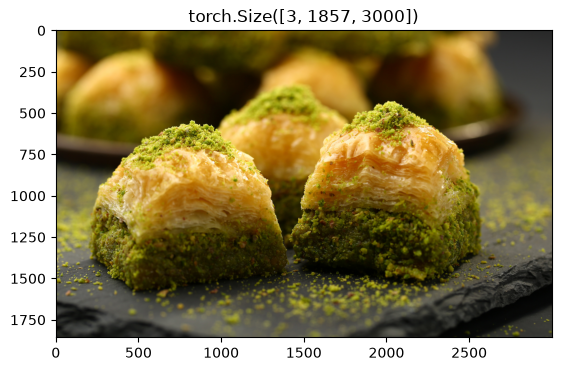

In [98]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)

In [100]:
single_image_transform = transforms.Compose(
    [
        transforms.Resize(size=(64,64))
    ]
)

single_image = single_image_transform(single_image)      

In [101]:
single_image.shape

torch.Size([3, 64, 64])

In [102]:
single_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [103]:
single_image = single_image.unsqueeze(dim=0)

In [104]:
model_0.eval()
with torch.inference_mode():
    logits = model_0(single_image)
    probs = torch.softmax(logits,dim=1)
    pred_idx = probs.argmax(dim=1).item()

print("Predicted class: ", class_names[pred_idx])

Predicted class:  baklava
